In [1]:
# Fast binary installs from Posit Package Manager (avoids slow source compiles in Colab)
codename <- system("grep VERSION_CODENAME /etc/os-release | cut -d= -f2", intern = TRUE)
options(repos = c(CRAN = sprintf("https://packagemanager.posit.co/cran/__linux__/%s/latest", codename)),
        HTTPUserAgent = sprintf("R/%s R (%s)", getRversion(),
                                paste(getRversion(), R.version$platform, R.version$arch, R.version$os)))

pkgs <- c("data.table", "ggplot2", "foreach", "doParallel", "microbenchmark",
          "purrr", "lubridate", "scales", "arrow", "leaflet", "htmlwidgets")
miss <- setdiff(pkgs, rownames(installed.packages()))
if (length(miss)) install.packages(miss, quiet = TRUE)

suppressPackageStartupMessages({
  library(data.table); library(ggplot2); library(foreach); library(doParallel)
  library(microbenchmark); library(purrr); library(lubridate); library(scales)
})
options(repr.plot.width = 10, repr.plot.height = 5, scipen = 999)
theme_set(theme_minimal(base_size = 12))
cat("Cores available:", parallel::detectCores(), "| data.table threads:", getDTthreads(), "\n")

YEAR   <- 2023
MONTHS <- 1:3        # 1:3 ~ 9M rows (safe on free Colab). Use 1:6 only on a high-RAM runtime.
set.seed(42)

also installing the dependencies ‘proxy’, ‘e1071’, ‘wk’, ‘lazyeval’, ‘sp’, ‘terra’, ‘classInt’, ‘s2’, ‘units’, ‘iterators’, ‘assertthat’, ‘crosstalk’, ‘leaflet.providers’, ‘png’, ‘raster’, ‘sf’




Cores available: 2 | data.table threads: 1 


In [2]:
BASE  <- "https://d37ci6vzurychx.cloudfront.net/trip-data/"
files <- sprintf("yellow_tripdata_%d-%02d.parquet", YEAR, MONTHS)
dir.create("data", showWarnings = FALSE)
for (f in files) if (!file.exists(file.path("data", f)))
  download.file(paste0(BASE, f), file.path("data", f), mode = "wb", quiet = TRUE)

keep <- c("tpep_pickup_datetime", "tpep_dropoff_datetime", "passenger_count", "trip_distance",
          "PULocationID", "DOLocationID", "payment_type", "fare_amount", "tip_amount",
          "tolls_amount", "total_amount")          # load only needed columns -> less memory

t_load <- system.time(
  taxi <- rbindlist(lapply(file.path("data", files), function(f)
    as.data.table(arrow::read_parquet(f, col_select = keep))))
)
cat("Loaded in", round(t_load[["elapsed"]], 1), "sec\n")

Warning message:
“Using an external vector in selections was deprecated in tidyselect 1.1.0.
ℹ Please use `all_of()` or `any_of()` instead.
  # Was:
  data %>% select(keep)

  # Now:
  data %>% select(all_of(keep))

See <https://tidyselect.r-lib.org/reference/faq-external-vector.html>.”


Loaded in 3.5 sec


In [3]:
cat("Dimensions:", format(nrow(taxi), big.mark = ","), "rows x", ncol(taxi), "cols\n")
cat("Memory:", format(object.size(taxi), units = "MB"), "\n\n")
str(taxi)
summary(taxi)
cat("\nMissing values per column:\n"); print(colSums(is.na(taxi)))

Dimensions: 9,384,487 rows x 11 cols
Memory: 680.2 Mb 

Classes ‘data.table’ and 'data.frame':	9384487 obs. of  11 variables:
 $ tpep_pickup_datetime : POSIXct, format: "2023-01-01 00:32:10" "2023-01-01 00:55:08" ...
 $ tpep_dropoff_datetime: POSIXct, format: "2023-01-01 00:40:36" "2023-01-01 01:01:27" ...
 $ passenger_count      : num  1 1 1 0 1 1 1 1 1 1 ...
 $ trip_distance        : num  0.97 1.1 2.51 1.9 1.43 1.84 1.66 11.7 2.95 3.01 ...
 $ PULocationID         : int  161 43 48 138 107 161 239 142 164 141 ...
 $ DOLocationID         : int  141 237 238 7 79 137 143 200 236 107 ...
 $ payment_type         : int  2 1 1 1 1 1 1 1 1 2 ...
 $ fare_amount          : num  9.3 7.9 14.9 12.1 11.4 12.8 12.1 45.7 17.7 14.9 ...
 $ tip_amount           : num  0 4 15 0 3.28 ...
 $ tolls_amount         : num  0 0 0 0 0 0 0 3 0 0 ...
 $ total_amount         : num  14.3 16.9 34.9 20.9 19.7 ...
 - attr(*, ".internal.selfref")=<pointer: 0x556c686d73f0> 


 tpep_pickup_datetime          tpep_dropoff_datetime         passenger_count 
 Min.   :2001-01-01 00:06:49   Min.   :2001-01-01 14:13:51   Min.   :0.000   
 1st Qu.:2023-01-24 23:33:22   1st Qu.:2023-01-24 23:48:47   1st Qu.:1.000   
 Median :2023-02-16 14:58:37   Median :2023-02-16 15:17:08   Median :1.000   
 Mean   :2023-02-16 05:29:55   Mean   :2023-02-16 05:46:08   Mean   :1.355   
 3rd Qu.:2023-03-10 14:34:35   3rd Qu.:2023-03-10 14:54:20   3rd Qu.:1.000   
 Max.   :2023-04-05 20:17:42   Max.   :2023-04-05 20:35:28   Max.   :9.000   
                                                             NAs    :236179  
 trip_distance        PULocationID  DOLocationID    payment_type  
 Min.   :     0.00   Min.   :  1   Min.   :  1.0   Min.   :0.000  
 1st Qu.:     1.06   1st Qu.:132   1st Qu.:114.0   1st Qu.:1.000  
 Median :     1.79   Median :162   Median :162.0   Median :1.000  
 Mean   :     3.87   Mean   :166   Mean   :164.2   Mean   :1.188  
 3rd Qu.:     3.33   3rd Qu.:234   3rd Qu


Missing values per column:
 tpep_pickup_datetime tpep_dropoff_datetime       passenger_count 
                    0                     0                236179 
        trip_distance          PULocationID          DOLocationID 
                    0                     0                     0 
         payment_type           fare_amount            tip_amount 
                    0                     0                     0 
         tolls_amount          total_amount 
                    0                     0 


In [4]:
n_raw <- nrow(taxi)
taxi  <- na.omit(taxi);  n_after_na  <- nrow(taxi)
taxi  <- unique(taxi);   n_after_dup <- nrow(taxi)
cat("Removed", format(n_raw - n_after_na, big.mark = ","), "rows with missing values and",
    format(n_after_na - n_after_dup, big.mark = ","), "duplicates\n")

Removed 236,179 rows with missing values and 0 duplicates


In [5]:
PAY_LABELS <- c("Flex fare", "Credit card", "Cash", "No charge", "Dispute", "Unknown", "Voided trip")

taxi[, `:=`(PULocationID    = as.integer(PULocationID),
            DOLocationID    = as.integer(DOLocationID),
            passenger_count = as.integer(passenger_count),
            payment_type    = factor(as.integer(payment_type), levels = 0:6, labels = PAY_LABELS))]

taxi[, `:=`(pickup_date  = as.IDate(tpep_pickup_datetime),
            hour         = hour(tpep_pickup_datetime),
            day          = mday(tpep_pickup_datetime),
            dow          = factor(wday(tpep_pickup_datetime), levels = c(2:7, 1),
                                  labels = c("Mon","Tue","Wed","Thu","Fri","Sat","Sun")),
            month        = month(tpep_pickup_datetime),
            duration_min = as.numeric(difftime(tpep_dropoff_datetime, tpep_pickup_datetime, units = "mins")))]
str(taxi[, .(pickup_date, hour, day, dow, month, duration_min, payment_type)])

Classes ‘data.table’ and 'data.frame':	9148308 obs. of  7 variables:
 $ pickup_date : IDate, format: "2023-01-01" "2023-01-01" ...
 $ hour        : int  0 0 0 0 0 0 0 0 0 0 ...
 $ day         : int  1 1 1 1 1 1 1 1 1 1 ...
 $ dow         : Factor w/ 7 levels "Mon","Tue","Wed",..: 7 7 7 7 7 7 7 7 7 7 ...
 $ month       : num  1 1 1 1 1 1 1 1 1 1 ...
 $ duration_min: num  8.43 6.32 12.75 9.62 10.83 ...
 $ payment_type: Factor w/ 7 levels "Flex fare","Credit card",..: 3 2 2 2 2 2 2 2 2 3 ...
 - attr(*, ".internal.selfref")=<pointer: 0x556c686d73f0> 


In [6]:
n_before <- nrow(taxi)
taxi <- taxi[year(pickup_date) == YEAR & month %in% MONTHS &          # stray dates outside the file's month
             passenger_count %between% c(1, 6) &
             trip_distance > 0 & trip_distance <= 100 &
             fare_amount > 0 & fare_amount <= 500 &
             total_amount > 0 & total_amount <= 1000 &
             tip_amount >= 0 & tolls_amount >= 0 &
             duration_min >= 1 & duration_min <= 180 &                 # dropoff after pickup, <= 3 hours
             !is.na(payment_type) &
             PULocationID %between% c(1L, 265L) & DOLocationID %between% c(1L, 265L)]
taxi[, speed_mph := trip_distance / (duration_min / 60)]
taxi <- taxi[speed_mph <= 80]                                         # implausible speeds
n_invalid <- n_before - nrow(taxi)

clean_log <- data.table(step = c("Raw rows", "Missing removed", "Duplicates removed", "Invalid removed", "Clean rows"),
                        rows = c(n_raw, n_raw - n_after_na, n_after_na - n_after_dup, n_invalid, nrow(taxi)))
print(clean_log)

                 step    rows
               <char>   <int>
1:           Raw rows 9384487
2:    Missing removed  236179
3: Duplicates removed       0
4:    Invalid removed  376542
5:         Clean rows 8771766


In [7]:
before <- object.size(taxi)
taxi[, c("tpep_pickup_datetime", "tpep_dropoff_datetime") := NULL]   # delete by reference
invisible(gc())
cat("Memory:", format(before, units = "MB"), "->", format(object.size(taxi), units = "MB"), "\n")

zf <- "data/taxi_zone_lookup.csv"
if (!file.exists(zf)) download.file("https://d37ci6vzurychx.cloudfront.net/misc/taxi_zone_lookup.csv", zf, quiet = TRUE)
zones <- fread(zf)
setkey(zones, LocationID)

# update-join by reference (no copy of the big table)
taxi[zones, on = c(PULocationID = "LocationID"), `:=`(PU_Borough = i.Borough, PU_Zone = i.Zone)]
taxi[zones, on = c(DOLocationID = "LocationID"), `:=`(DO_Borough = i.Borough, DO_Zone = i.Zone)]

cat("Unmatched pickups:", sum(is.na(taxi$PU_Zone)), "| unmatched drop-offs:", sum(is.na(taxi$DO_Zone)), "\n")
head(taxi)

Memory: 936.9 Mb -> 803.1 Mb 
Unmatched pickups: 0 | unmatched drop-offs: 0 


passenger_count,trip_distance,PULocationID,DOLocationID,payment_type,fare_amount,tip_amount,tolls_amount,total_amount,pickup_date,hour,day,dow,month,duration_min,speed_mph,PU_Borough,PU_Zone,DO_Borough,DO_Zone
<int>,<dbl>,<int>,<int>,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<IDate>,<int>,<int>,<fct>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>
1,0.97,161,141,Cash,9.3,0.00,0,14.30,2023-01-01,0,1,Sun,1,8.433333,6.901186,Manhattan,Midtown Center,Manhattan,Lenox Hill West
1,1.10,43,237,Credit card,7.9,4.00,0,16.90,2023-01-01,0,1,Sun,1,6.316667,10.448549,Manhattan,Central Park,Manhattan,Upper East Side South
1,2.51,48,238,Credit card,14.9,15.00,0,34.90,2023-01-01,0,1,Sun,1,12.750000,11.811765,Manhattan,Clinton East,Manhattan,Upper West Side North
1,1.43,107,79,Credit card,11.4,3.28,0,19.68,2023-01-01,0,1,Sun,1,10.833333,7.920000,Manhattan,Gramercy,Manhattan,East Village
1,1.84,161,137,Credit card,12.8,10.00,0,27.80,2023-01-01,0,1,Sun,1,12.300000,8.975610,Manhattan,Midtown Center,Manhattan,Kips Bay
1,1.66,239,143,Credit card,12.1,3.42,0,20.52,2023-01-01,0,1,Sun,1,10.450000,9.531100,Manhattan,Upper West Side South,Manhattan,Lincoln Square West


In [8]:
agg <- function(by) taxi[, .(trips = .N, avg_fare = round(mean(fare_amount), 2),
                             total_revenue = round(sum(total_amount))), by = by]
hourly  <- agg("hour")[order(hour)]
weekly  <- agg("dow")[order(dow)]
monthly <- agg("month")[order(month)]
daily   <- taxi[, .(trips = .N, revenue = sum(total_amount)), by = pickup_date][order(pickup_date)]

print(hourly); print(weekly); print(monthly)
cat(sprintf("\nInterpretation: peak demand at %02d:00 (%s trips), quietest at %02d:00. Busiest day: %s; quietest: %s. Busiest month: %d.\n",
  hourly[which.max(trips), hour], format(hourly[which.max(trips), trips], big.mark = ","), hourly[which.min(trips), hour],
  weekly[which.max(trips), dow], weekly[which.min(trips), dow], monthly[which.max(trips), month]))

     hour  trips avg_fare total_revenue
    <int>  <int>    <num>         <num>
 1:     0 237093    19.64       6803204
 2:     1 159184    17.77       4178585
 3:     2 103581    16.69       2570352
 4:     3  70435    17.75       1836206
 5:     4  44785    22.84       1453084
 6:     5  47390    27.00       1785114
 7:     6 120236    22.61       3762834
 8:     7 240799    18.95       6492084
 9:     8 332464    17.55       8424453
10:     9 376713    17.86       9736367
11:    10 408133    17.90      10546179
12:    11 442365    17.85      11394535
13:    12 480499    18.25      12626532
14:    13 498654    18.99      13554228
15:    14 539424    19.98      15363905
16:    15 550756    19.66      15418501
17:    16 552379    19.68      16569069
18:    17 601285    18.59      17289863
19:    18 629295    17.19      17053567
20:    19 564121    17.57      15544715
21:    20 493263    18.02      13384852
22:    21 485931    18.42      13414392
23:    22 446348    19.28      12728886


In [9]:
# group on integer IDs first (fast), attach zone names to the small result afterwards
routes <- taxi[, .(trips = .N, revenue = sum(total_amount), avg_fare = mean(fare_amount),
                   avg_dist = mean(trip_distance)), by = .(PULocationID, DOLocationID)]
routes[zones, on = c(PULocationID = "LocationID"), PU_Zone := i.Zone]
routes[zones, on = c(DOLocationID = "LocationID"), DO_Zone := i.Zone]
routes[, route := paste(PU_Zone, DO_Zone, sep = " -> ")]

top_routes <- routes[order(-trips)][1:10]
top_rev    <- routes[order(-revenue)][1:10]
print(top_routes[, .(route, trips, revenue = round(revenue), avg_fare = round(avg_fare, 2))])
print(top_rev[, .(route, trips, revenue = round(revenue), avg_fare = round(avg_fare, 2))])

                                             route trips revenue avg_fare
                                            <char> <int>   <num>    <num>
 1: Upper East Side South -> Upper East Side North 61242  944580     8.64
 2:                                     N/A -> N/A 54945 1496396    19.08
 3: Upper East Side North -> Upper East Side South 52079  836099     9.28
 4: Upper East Side North -> Upper East Side North 39481  518740     6.71
 5: Upper East Side South -> Upper East Side South 38506  524206     7.15
 6:        Midtown Center -> Upper East Side South 27372  461797     9.78
 7:        Upper East Side South -> Midtown Center 26711  440463     9.82
 8:        Midtown Center -> Upper East Side North 24896  536919    13.66
 9:   Lincoln Square East -> Upper West Side South 23532  351272     8.02
10: Upper West Side South -> Upper West Side North 23205  320894     7.18
                                             route trips revenue avg_fare
                                      

In [10]:
# group on integer IDs first (fast), attach zone names to the small result afterwards
routes <- taxi[, .(trips = .N, revenue = sum(total_amount), avg_fare = mean(fare_amount),
                   avg_dist = mean(trip_distance)), by = .(PULocationID, DOLocationID)]
routes[zones, on = c(PULocationID = "LocationID"), PU_Zone := i.Zone]
routes[zones, on = c(DOLocationID = "LocationID"), DO_Zone := i.Zone]
routes[, route := paste(PU_Zone, DO_Zone, sep = " -> ")]

top_routes <- routes[order(-trips)][1:10]
top_rev    <- routes[order(-revenue)][1:10]
print(top_routes[, .(route, trips, revenue = round(revenue), avg_fare = round(avg_fare, 2))])
print(top_rev[, .(route, trips, revenue = round(revenue), avg_fare = round(avg_fare, 2))])

                                             route trips revenue avg_fare
                                            <char> <int>   <num>    <num>
 1: Upper East Side South -> Upper East Side North 61242  944580     8.64
 2:                                     N/A -> N/A 54945 1496396    19.08
 3: Upper East Side North -> Upper East Side South 52079  836099     9.28
 4: Upper East Side North -> Upper East Side North 39481  518740     6.71
 5: Upper East Side South -> Upper East Side South 38506  524206     7.15
 6:        Midtown Center -> Upper East Side South 27372  461797     9.78
 7:        Upper East Side South -> Midtown Center 26711  440463     9.82
 8:        Midtown Center -> Upper East Side North 24896  536919    13.66
 9:   Lincoln Square East -> Upper West Side South 23532  351272     8.02
10: Upper West Side South -> Upper West Side North 23205  320894     7.18
                                             route trips revenue avg_fare
                                      

In [11]:
# group on integer IDs first (fast), attach zone names to the small result afterwards
routes <- taxi[, .(trips = .N, revenue = sum(total_amount), avg_fare = mean(fare_amount),
                   avg_dist = mean(trip_distance)), by = .(PULocationID, DOLocationID)]
routes[zones, on = c(PULocationID = "LocationID"), PU_Zone := i.Zone]
routes[zones, on = c(DOLocationID = "LocationID"), DO_Zone := i.Zone]
routes[, route := paste(PU_Zone, DO_Zone, sep = " -> ")]

top_routes <- routes[order(-trips)][1:10]
top_rev    <- routes[order(-revenue)][1:10]
print(top_routes[, .(route, trips, revenue = round(revenue), avg_fare = round(avg_fare, 2))])
print(top_rev[, .(route, trips, revenue = round(revenue), avg_fare = round(avg_fare, 2))])

                                             route trips revenue avg_fare
                                            <char> <int>   <num>    <num>
 1: Upper East Side South -> Upper East Side North 61242  944580     8.64
 2:                                     N/A -> N/A 54945 1496396    19.08
 3: Upper East Side North -> Upper East Side South 52079  836099     9.28
 4: Upper East Side North -> Upper East Side North 39481  518740     6.71
 5: Upper East Side South -> Upper East Side South 38506  524206     7.15
 6:        Midtown Center -> Upper East Side South 27372  461797     9.78
 7:        Upper East Side South -> Midtown Center 26711  440463     9.82
 8:        Midtown Center -> Upper East Side North 24896  536919    13.66
 9:   Lincoln Square East -> Upper West Side South 23532  351272     8.02
10: Upper West Side South -> Upper West Side North 23205  320894     7.18
                                             route trips revenue avg_fare
                                      

In [12]:
cat("Pearson correlation (distance, fare):", round(taxi[, cor(trip_distance, fare_amount)], 4), "\n")
fit <- lm(fare_amount ~ trip_distance, data = taxi[sample(.N, min(.N, 1e6))])
cat(sprintf("Fare ~ %.2f + %.2f x miles  (R^2 = %.3f)\n", coef(fit)[1], coef(fit)[2], summary(fit)$r.squared))

dist_bins <- taxi[, .(trips = .N, avg_fare = round(mean(fare_amount), 2),
                      fare_per_mile = round(sum(fare_amount) / sum(trip_distance), 2)),
                  by = .(dist_bin = cut(trip_distance, c(0, 1, 2, 5, 10, 20, Inf),
                                        labels = c("<1", "1-2", "2-5", "5-10", "10-20", "20+")))][order(dist_bin)]
print(dist_bins)

Pearson correlation (distance, fare): 0.9634 
Fare ~ 6.06 + 3.70 x miles  (R^2 = 0.928)
   dist_bin   trips avg_fare fare_per_mile
     <fctr>   <int>    <num>         <num>
1:       <1 1944962     7.36         10.26
2:      1-2 2937922    11.32          7.70
3:      2-5 2431485    18.43          6.12
4:     5-10  737868    33.87          4.66
5:    10-20  629053    61.40          4.10
6:      20+   90476    87.61          3.72


In [13]:
pay_borough <- taxi[, .N, by = .(PU_Borough, payment_type)][, pct := round(100 * N / sum(N), 1), by = PU_Borough]
print(dcast(pay_borough, PU_Borough ~ payment_type, value.var = "pct", fill = 0))
pay_total <- taxi[, .(trips = .N, pct = round(100 * .N / nrow(taxi), 2)), by = payment_type][order(-trips)]
print(pay_total)

Key: <PU_Borough>
      PU_Borough Credit card  Cash No charge Dispute
          <char>       <num> <num>     <num>   <num>
1:         Bronx        82.8  16.1       0.5     0.7
2:      Brooklyn        80.3  18.4       0.6     0.8
3:           EWR        70.1  22.4       6.0     1.5
4:     Manhattan        82.7  16.5       0.3     0.5
5:           N/A        68.6  26.3       2.1     3.0
6:        Queens        77.2  21.6       0.4     0.7
7: Staten Island        95.2   4.4       0.2     0.2
8:       Unknown        81.5  17.5       0.2     0.7
   payment_type   trips   pct
         <fctr>   <int> <num>
1:  Credit card 7208798 82.18
2:         Cash 1489059 16.98
3:      Dispute   47261  0.54
4:    No charge   26648  0.30


In [14]:
tip_hour   <- taxi[payment_type == "Credit card", .(tip_pct = round(100 * sum(tip_amount) / sum(fare_amount), 2)), by = hour][order(hour)]
speed_hour <- taxi[, .(avg_speed_mph = round(mean(speed_mph), 1)), by = hour][order(hour)]

airport_ids <- zones[grepl("Airport", Zone), LocationID]
airport <- taxi[, .(trips = .N, avg_fare = round(mean(fare_amount), 2), avg_dist = round(mean(trip_distance), 2),
                    revenue = round(sum(total_amount))), by = .(airport_trip = PULocationID %in% airport_ids | DOLocationID %in% airport_ids)]
print(airport)
cat(sprintf("Credit-card tip rate peaks at %02d:00 (%.1f%%). Slowest average speed at %02d:00 (%.1f mph), fastest at %02d:00 (%.1f mph).\n",
    tip_hour[which.max(tip_pct), hour], tip_hour[, max(tip_pct)],
    speed_hour[which.min(avg_speed_mph), hour], speed_hour[, min(avg_speed_mph)],
    speed_hour[which.max(avg_speed_mph), hour], speed_hour[, max(avg_speed_mph)]))

   airport_trip   trips avg_fare avg_dist   revenue
         <lgcl>   <int>    <num>    <num>     <num>
1:        FALSE 7876576    14.49     2.25 174251642
2:         TRUE  895190    55.67    13.66  68002045
Credit-card tip rate peaks at 18:00 (24.0%). Slowest average speed at 15:00 (10.1 mph), fastest at 05:00 (20.6 mph).


In [15]:
peak_mem_mb <- function(expr) {                 # extra peak memory (MB) while evaluating expr
  g0 <- gc(reset = TRUE); base <- sum(g0[, 2])
  invisible(expr)
  g1 <- gc(); max(0, sum(g1[, 6]) - base)
}
benchmark_impls <- function(impl, times = 5, category = "") {
  res <- rbindlist(lapply(names(impl), function(n) {
    f  <- impl[[n]]
    mb <- microbenchmark(f(), times = times, control = list(warmup = 1))
    data.table(category = category, method = n, median_ms = median(mb$time) / 1e6,
               min_ms = min(mb$time) / 1e6, peak_mem_mb = round(peak_mem_mb(f()), 1))
  }))
  res[, relative := round(median_ms / min(median_ms), 1)][]
}
bench_all <- list()

In [16]:
samp <- taxi[sample(.N, min(.N, 2e5)), .(fare_amount, trip_distance)]
n <- nrow(samp); fare <- samp$fare_amount; dist <- samp$trip_distance

rowwise <- list(
  "apply() over matrix rows"  = function() apply(as.matrix(samp), 1, function(r) r[1] / r[2]),
  "lapply() over row index"   = function() unlist(lapply(seq_len(n), function(i) fare[i] / dist[i])),
  "purrr::map2_dbl()"         = function() map2_dbl(fare, dist, ~ .x / .y),
  "Vectorized base R"         = function() fare / dist,
  "data.table"                = function() samp[, fare_amount / trip_distance]
)
stopifnot(all.equal(unname(rowwise[[1]]()), fare / dist))   # identical results

bench_all$rowwise <- benchmark_impls(rowwise, times = 5, category = "A. Row-wise fare per mile (200k rows)")
print(bench_all$rowwise)

                                category                   method   median_ms
                                  <char>                   <char>       <num>
1: A. Row-wise fare per mile (200k rows) apply() over matrix rows 1175.536833
2: A. Row-wise fare per mile (200k rows)  lapply() over row index  175.093275
3: A. Row-wise fare per mile (200k rows)        purrr::map2_dbl()  255.660729
4: A. Row-wise fare per mile (200k rows)        Vectorized base R    0.294071
5: A. Row-wise fare per mile (200k rows)               data.table    0.831941
       min_ms peak_mem_mb relative
        <num>       <num>    <num>
1: 810.792684       188.2   3997.5
2: 156.644511       102.2    595.4
3: 242.716173       173.4    869.4
4:   0.289410         1.5      1.0
5:   0.759631         1.7      2.8


In [17]:
gd  <- taxi[, .(hour, fare_amount)]
hrs <- 0:23

groupwise <- list(
  "Base aggregate() formula"    = function() aggregate(fare_amount ~ hour, data = gd, FUN = mean),
  "Base tapply()"               = function() tapply(gd$fare_amount, gd$hour, mean),
  "lapply() over hours"         = function() unlist(lapply(hrs, function(h) mean(gd$fare_amount[gd$hour == h]))),
  "purrr::map_dbl() over hours" = function() map_dbl(hrs, ~ mean(gd$fare_amount[gd$hour == .x])),
  "split() + sapply()"          = function() sapply(split(gd$fare_amount, gd$hour), mean),
  "data.table by="              = function() gd[, mean(fare_amount), by = hour]
)
stopifnot(all.equal(as.vector(groupwise[["Base tapply()"]]()), gd[, mean(fare_amount), keyby = hour]$V1))

bench_all$groupwise <- benchmark_impls(groupwise, times = 3, category = "B. Group-wise mean fare by hour (full data)")
print(bench_all$groupwise)
rm(gd); invisible(gc())

                                      category                      method
                                        <char>                      <char>
1: B. Group-wise mean fare by hour (full data)    Base aggregate() formula
2: B. Group-wise mean fare by hour (full data)               Base tapply()
3: B. Group-wise mean fare by hour (full data)         lapply() over hours
4: B. Group-wise mean fare by hour (full data) purrr::map_dbl() over hours
5: B. Group-wise mean fare by hour (full data)          split() + sapply()
6: B. Group-wise mean fare by hour (full data)              data.table by=
   median_ms    min_ms peak_mem_mb relative
       <num>     <num>       <num>    <num>
1: 2774.9013 2649.4371      1187.3     11.5
2:  393.8066  390.5543       362.3      1.6
3:  708.0176  684.7376      1197.3      2.9
4:  707.7903  691.2109      1197.4      2.9
5:  430.3536  369.5425       295.4      1.8
6:  242.0776  226.0900       246.5      1.0


In [18]:
heavy_task <- function(d, B = 40, n = 250000) {
  set.seed(d$month[1])
  slopes <- vapply(seq_len(B), function(b) {
    s   <- d[sample.int(.N, min(n, .N))]
    fit <- lm(total_amount ~ trip_distance + duration_min, data = s)
    unname(coef(fit)["trip_distance"])
  }, numeric(1))
  data.table(month = d$month[1], rows = nrow(d), slope_mean = mean(slopes),
             slope_lo = quantile(slopes, 0.025), slope_hi = quantile(slopes, 0.975))
}

parts <- split(taxi[, .(month, total_amount, trip_distance, duration_min)], by = "month")
parts <- parts[order(as.integer(names(parts)))]       # month order
cat("Partitions:", paste(names(parts), sapply(parts, nrow), sep = ": ", collapse = " | "), "\n")

# ---- Sequential ----
t_seq <- system.time(res_seq <- rbindlist(lapply(parts, heavy_task)))
cat("Sequential elapsed:", round(t_seq[["elapsed"]], 2), "sec\n")
print(res_seq)

Partitions: 1: 2872758 | 2: 2721764 | 3: 3177244 
Sequential elapsed: 5.08 sec
   month    rows slope_mean slope_lo slope_hi
   <num>   <int>      <num>    <num>    <num>
1:     1 2872758   3.931265 3.901972 3.968964
2:     2 2721764   3.931764 3.903045 3.969899
3:     3 3177244   3.878551 3.857013 3.910907


In [19]:
max_cores <- parallel::detectCores()
core_set  <- unique(c(1, 2, max_cores)); core_set <- core_set[core_set <= max(max_cores, 2)]

par_results <- rbindlist(lapply(core_set, function(k) {
  t_start <- system.time(cl <- makeCluster(k))                  # worker start-up cost
  registerDoParallel(cl)
  t_par <- system.time(
    res_par <- foreach(d = parts, .combine = rbind, .packages = "data.table", .export = "heavy_task") %dopar% heavy_task(d)
  )
  stopCluster(cl)
  stopifnot(isTRUE(all.equal(as.data.frame(res_par), as.data.frame(res_seq), check.attributes = FALSE)))
  data.table(workers = k, cluster_startup_s = round(t_start[["elapsed"]], 2), parallel_s = round(t_par[["elapsed"]], 2))
}))

par_results[, `:=`(sequential_s = round(t_seq[["elapsed"]], 2),
                   speedup    = round(t_seq[["elapsed"]] / parallel_s, 2))]
par_results[, efficiency_pct := round(100 * speedup / workers, 1)]
print(par_results)

best <- par_results[which.max(speedup)]
cat(sprintf("Speedup = Sequential / Parallel = %.2f s / %.2f s = %.2fx with %d workers (efficiency %.0f%%).\n",
            best$sequential_s, best$parallel_s, best$speedup, best$workers, best$efficiency_pct))
cat(if (best$speedup >= 1.5) "Parallel processing gave a meaningful improvement. "
    else if (best$speedup >= 1) "Parallel processing gave only a limited improvement. "
    else "Parallel processing was slower than sequential here. ",
    "Limiting factors: only ", length(parts), " month-partitions (load imbalance when partitions > workers), ",
    "serialization of each partition to the workers, worker start-up time, and few cores on Colab (Amdahl's law).\n", sep = "")

   workers cluster_startup_s parallel_s sequential_s speedup efficiency_pct
     <num>             <num>      <num>        <num>   <num>          <num>
1:       1              0.18       6.75         5.08    0.75           75.0
2:       2              0.22       6.15         5.08    0.83           41.5
Speedup = Sequential / Parallel = 5.08 s / 6.15 s = 0.83x with 2 workers (efficiency 42%).
Parallel processing was slower than sequential here. Limiting factors: only 3 month-partitions (load imbalance when partitions > workers), serialization of each partition to the workers, worker start-up time, and few cores on Colab (Amdahl's law).


In [20]:
s2_df <- as.data.frame(taxi[sample(.N, min(.N, 2e6)), .(PULocationID, fare_amount, total_amount)])
s2_dt <- as.data.table(s2_df)
z_df  <- as.data.frame(zones)

base_vs_dt <- list(
  "Base R: merge() + aggregate()" = function() {
    m <- merge(s2_df, z_df, by.x = "PULocationID", by.y = "LocationID")
    aggregate(total_amount ~ Borough, data = m, FUN = sum)
  },
  "data.table: join + by=" = function() {
    s2_dt[zones, on = c(PULocationID = "LocationID"), nomatch = NULL][, .(rev = sum(total_amount)), by = Borough]
  }
)
bench_all$join <- benchmark_impls(base_vs_dt, times = 3, category = "C. Join + aggregate by borough (2M rows)")

sort_impl <- list(
  "Base R: order()"     = function() s2_df[order(s2_df$total_amount), ],
  "data.table: order()" = function() s2_dt[order(total_amount)]
)
bench_all$sort <- benchmark_impls(sort_impl, times = 3, category = "D. Sort by total_amount (2M rows)")
print(rbind(bench_all$join, bench_all$sort))
rm(s2_df, s2_dt, z_df); invisible(gc())

                                   category                        method
                                     <char>                        <char>
1: C. Join + aggregate by borough (2M rows) Base R: merge() + aggregate()
2: C. Join + aggregate by borough (2M rows)        data.table: join + by=
3:        D. Sort by total_amount (2M rows)               Base R: order()
4:        D. Sort by total_amount (2M rows)           data.table: order()
   median_ms    min_ms peak_mem_mb relative
       <num>     <num>       <num>    <num>
1: 3614.0261 3225.1187      1108.8     20.3
2:  178.1233  149.0598       202.4      1.0
3:  192.7936  192.2911        69.4      1.4
4:  139.4467  133.6788        45.8      1.0


In [21]:
seq_row <- data.table(category = "E. Sequential vs parallel (monthly bootstrap)", method = "Sequential (lapply)",
                      median_ms = t_seq[["elapsed"]] * 1000, min_ms = t_seq[["elapsed"]] * 1000, peak_mem_mb = NA_real_)
par_rows <- par_results[, .(category = "E. Sequential vs parallel (monthly bootstrap)",
                            method = sprintf("foreach/doParallel (%d worker%s)", workers, ifelse(workers > 1, "s", "")),
                            median_ms = parallel_s * 1000, min_ms = parallel_s * 1000, peak_mem_mb = NA_real_)]
bench_all$parallel <- rbind(seq_row, par_rows)[, relative := round(median_ms / min(median_ms), 2)]

all_bench <- rbindlist(bench_all, fill = TRUE)
all_bench[, `:=`(median_ms = round(median_ms, 1), min_ms = round(min_ms, 1))]
print(all_bench[, .(category, method, median_ms, peak_mem_mb, relative)])
fwrite(all_bench, "benchmark_results.csv")

fastest <- all_bench[, .SD[which.min(median_ms)], by = category][, .(category, fastest = method, median_ms)]
print(fastest)

                                         category
                                           <char>
 1:         A. Row-wise fare per mile (200k rows)
 2:         A. Row-wise fare per mile (200k rows)
 3:         A. Row-wise fare per mile (200k rows)
 4:         A. Row-wise fare per mile (200k rows)
 5:         A. Row-wise fare per mile (200k rows)
 6:   B. Group-wise mean fare by hour (full data)
 7:   B. Group-wise mean fare by hour (full data)
 8:   B. Group-wise mean fare by hour (full data)
 9:   B. Group-wise mean fare by hour (full data)
10:   B. Group-wise mean fare by hour (full data)
11:   B. Group-wise mean fare by hour (full data)
12:      C. Join + aggregate by borough (2M rows)
13:      C. Join + aggregate by borough (2M rows)
14:             D. Sort by total_amount (2M rows)
15:             D. Sort by total_amount (2M rows)
16: E. Sequential vs parallel (monthly bootstrap)
17: E. Sequential vs parallel (monthly bootstrap)
18: E. Sequential vs parallel (monthly bootstrap)


Interpretation: demand is lowest around 04:00 and peaks at 18:00 (evening commute).


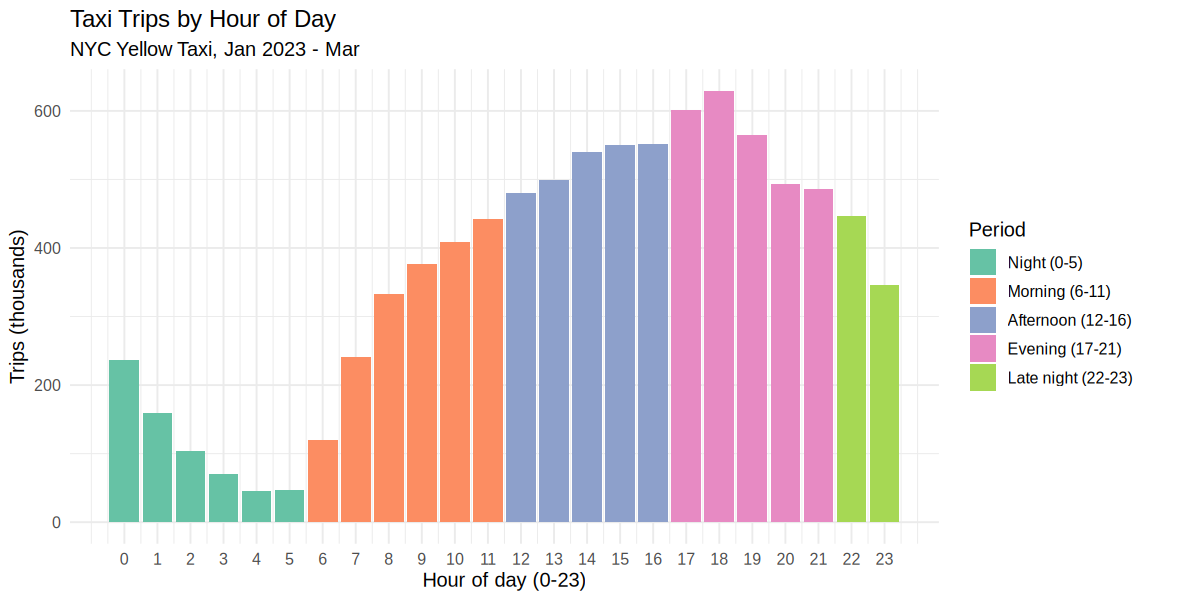

In [22]:
period_of <- function(h) cut(h, c(-1, 5, 11, 16, 21, 23),
                             labels = c("Night (0-5)", "Morning (6-11)", "Afternoon (12-16)", "Evening (17-21)", "Late night (22-23)"))
sub <- sprintf("NYC Yellow Taxi, %s 2023 - %s", month.abb[min(MONTHS)], month.abb[max(MONTHS)])

# 1. Trips by hour
ggplot(hourly[, period := period_of(hour)], aes(hour, trips / 1e3, fill = period)) +
  geom_col() + scale_x_continuous(breaks = 0:23) + scale_fill_brewer(palette = "Set2") +
  labs(title = "Taxi Trips by Hour of Day", subtitle = sub, x = "Hour of day (0-23)", y = "Trips (thousands)", fill = "Period")
cat(sprintf("Interpretation: demand is lowest around %02d:00 and peaks at %02d:00 (evening commute).\n", hourly[which.min(trips), hour], hourly[which.max(trips), hour]))

Interpretation: Thu is the busiest day and Mon the quietest.


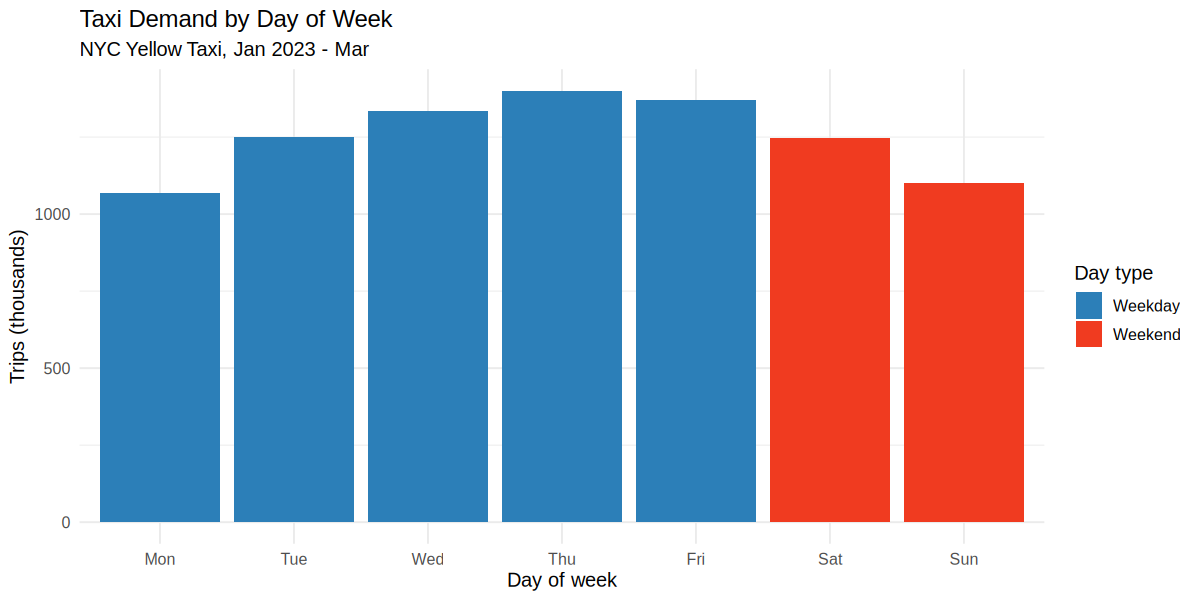

In [23]:
# 2. Demand by day of week
ggplot(weekly[, type := ifelse(dow %in% c("Sat", "Sun"), "Weekend", "Weekday")], aes(dow, trips / 1e3, fill = type)) +
  geom_col() + scale_fill_manual(values = c(Weekday = "#2c7fb8", Weekend = "#f03b20")) +
  labs(title = "Taxi Demand by Day of Week", subtitle = sub, x = "Day of week", y = "Trips (thousands)", fill = "Day type")
cat(sprintf("Interpretation: %s is the busiest day and %s the quietest.\n", weekly[which.max(trips), dow], weekly[which.min(trips), dow]))

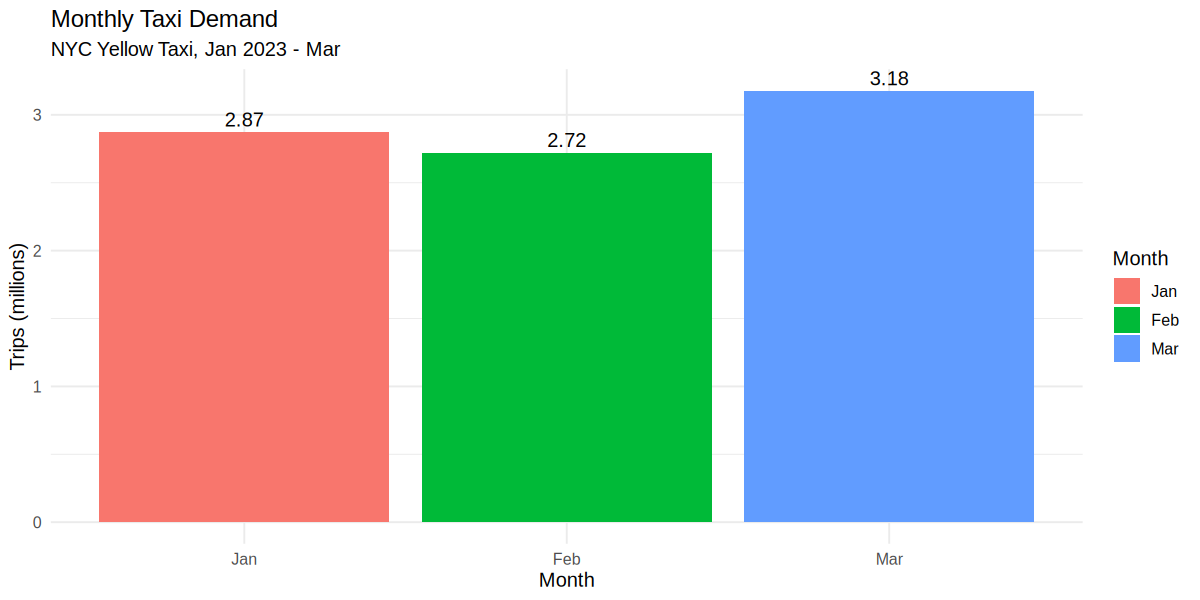

In [24]:
# 3. Monthly demand
ggplot(monthly[, mon := factor(month, levels = 1:12, labels = month.abb)], aes(mon, trips / 1e6, fill = mon)) +
  geom_col() + geom_text(aes(label = round(trips / 1e6, 2)), vjust = -0.4) +
  labs(title = "Monthly Taxi Demand", subtitle = sub, x = "Month", y = "Trips (millions)", fill = "Month")

Interpretation: average fare is highest at 05:00 ($27.00) - early-morning trips are longer (airport runs).


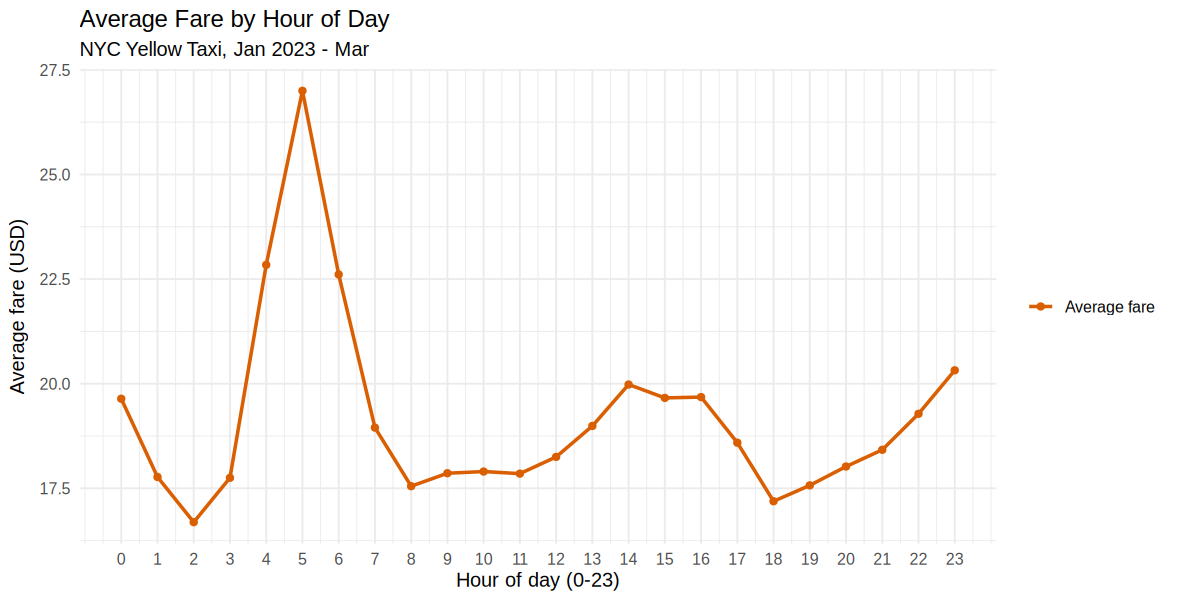

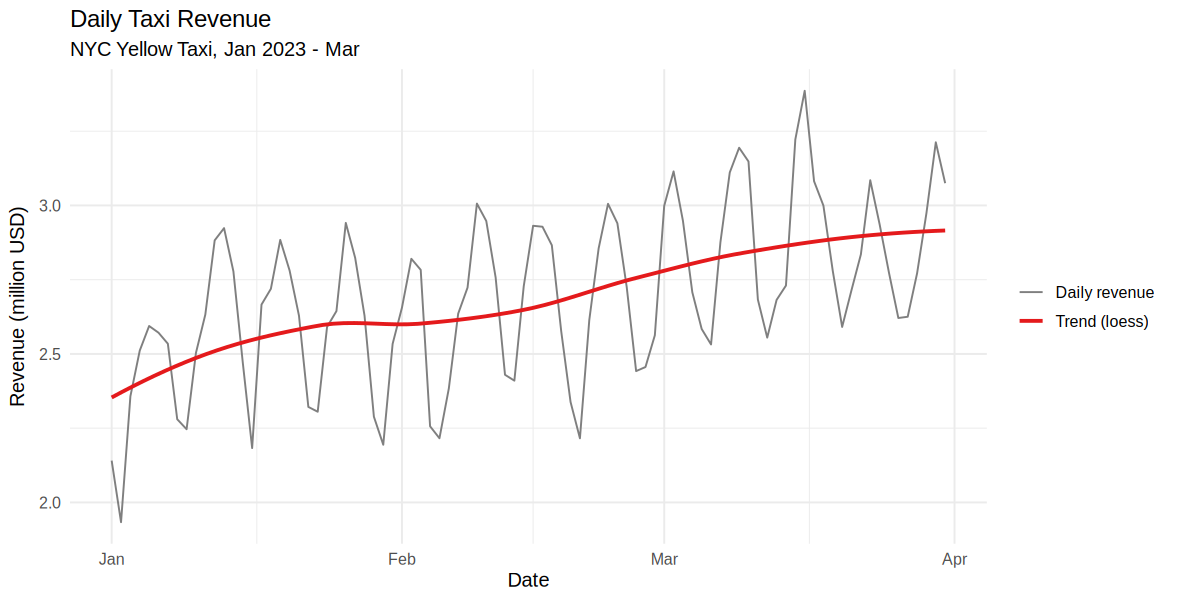

In [25]:
ggplot(hourly, aes(hour, avg_fare)) + geom_line(aes(colour = "Average fare"), linewidth = 1) + geom_point(aes(colour = "Average fare")) +
  scale_x_continuous(breaks = 0:23) + scale_colour_manual(values = c("Average fare" = "#d95f02")) +
  labs(title = "Average Fare by Hour of Day", subtitle = sub, x = "Hour of day (0-23)", y = "Average fare (USD)", colour = NULL)
cat(sprintf("Interpretation: average fare is highest at %02d:00 ($%.2f) - early-morning trips are longer (airport runs).\n",
            hourly[which.max(avg_fare), hour], hourly[, max(avg_fare)]))

ggplot(daily, aes(pickup_date, revenue / 1e6)) +
  geom_line(aes(colour = "Daily revenue")) + geom_smooth(aes(colour = "Trend (loess)"), se = FALSE, method = "loess", formula = y ~ x) +
  scale_colour_manual(values = c("Daily revenue" = "grey50", "Trend (loess)" = "#e41a1c")) +
  labs(title = "Daily Taxi Revenue", subtitle = sub, x = "Date", y = "Revenue (million USD)", colour = NULL)

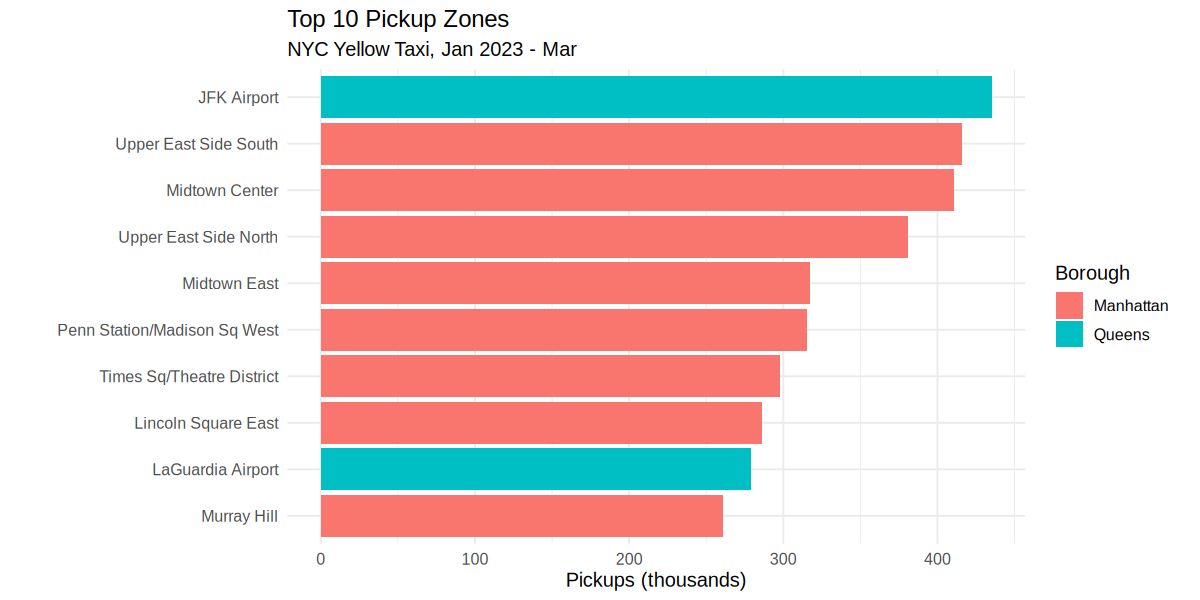

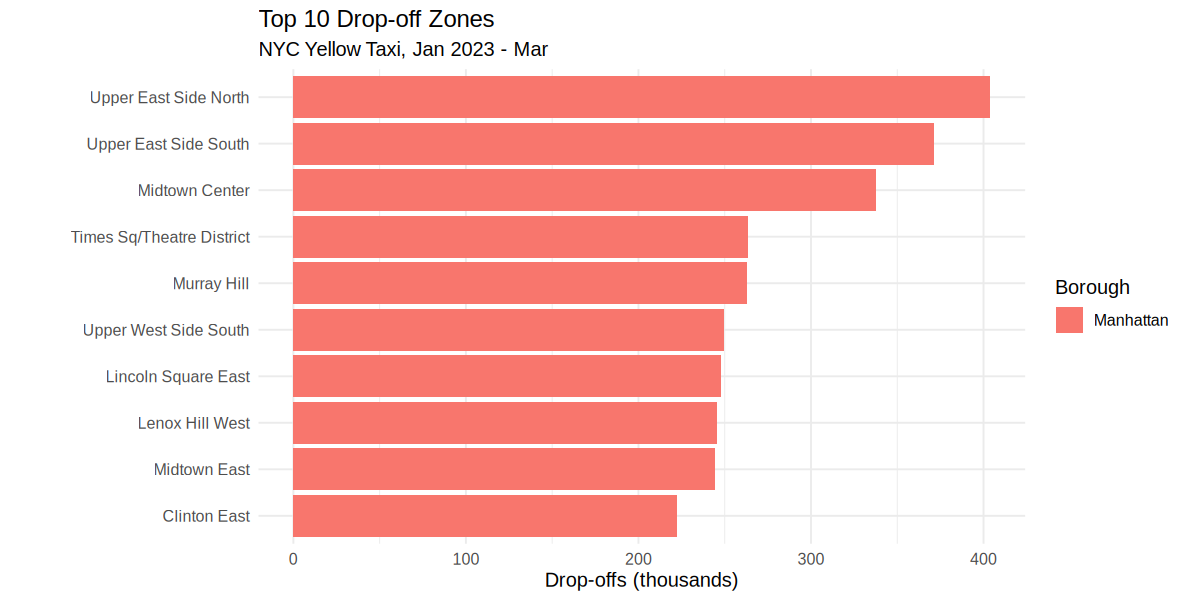

In [26]:
top_pu <- taxi[, .N, by = .(zone = PU_Zone, borough = PU_Borough)][order(-N)][1:10]
top_do <- taxi[, .N, by = .(zone = DO_Zone, borough = DO_Borough)][order(-N)][1:10]

ggplot(top_pu, aes(reorder(zone, N), N / 1e3, fill = borough)) + geom_col() + coord_flip() +
  labs(title = "Top 10 Pickup Zones", subtitle = sub, x = NULL, y = "Pickups (thousands)", fill = "Borough")
ggplot(top_do, aes(reorder(zone, N), N / 1e3, fill = borough)) + geom_col() + coord_flip() +
  labs(title = "Top 10 Drop-off Zones", subtitle = sub, x = NULL, y = "Drop-offs (thousands)", fill = "Borough")

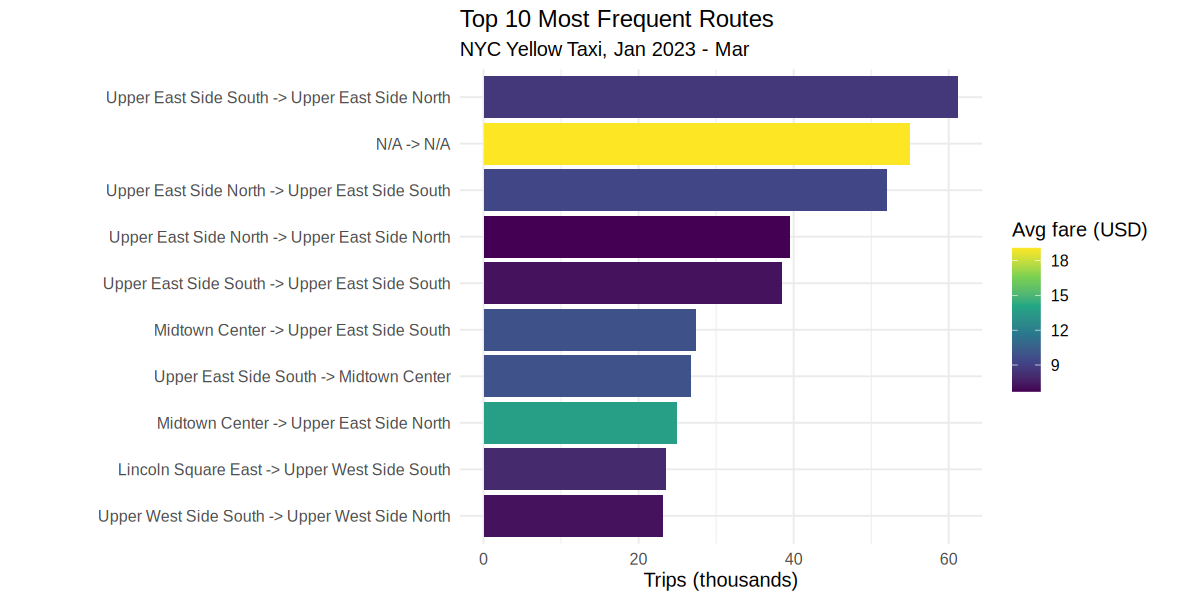

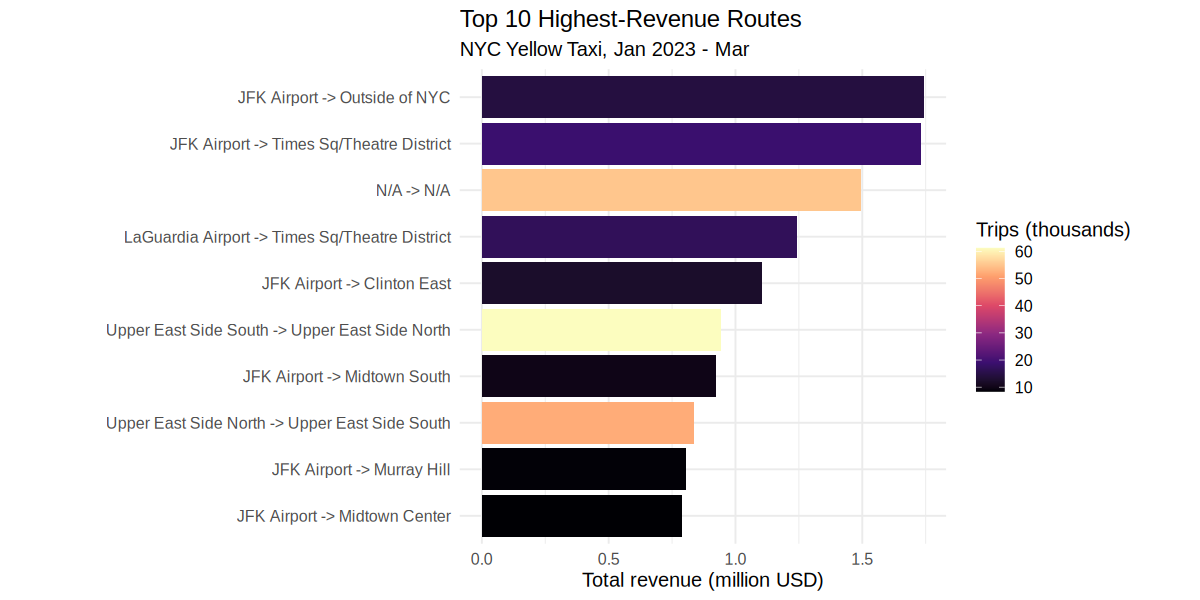

In [27]:
ggplot(top_routes, aes(reorder(route, trips), trips / 1e3, fill = avg_fare)) + geom_col() + coord_flip() +
  scale_fill_viridis_c() +
  labs(title = "Top 10 Most Frequent Routes", subtitle = sub, x = NULL, y = "Trips (thousands)", fill = "Avg fare (USD)")
ggplot(top_rev, aes(reorder(route, revenue), revenue / 1e6, fill = trips / 1e3)) + geom_col() + coord_flip() +
  scale_fill_viridis_c(option = "magma") +
  labs(title = "Top 10 Highest-Revenue Routes", subtitle = sub, x = NULL, y = "Total revenue (million USD)", fill = "Trips (thousands)")

Interpretation: Credit card dominates overall (82.2% of trips), followed by Cash (17.0%).


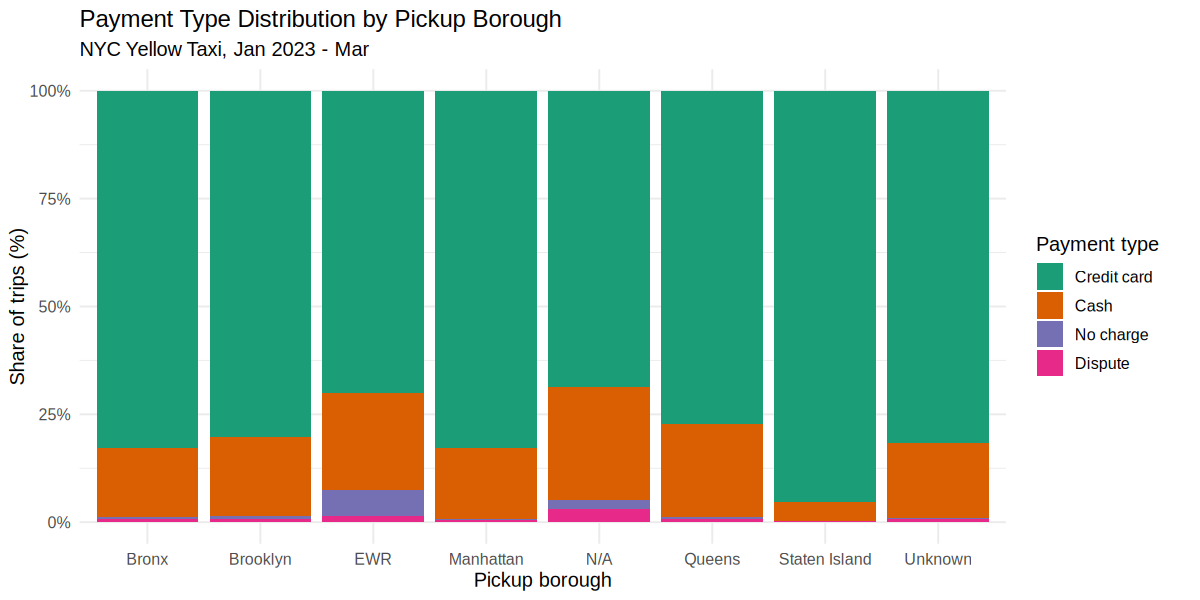

Interpretation: fare grows almost linearly with distance (metered rate); the horizontal band at ~$70 is the JFK flat fare.


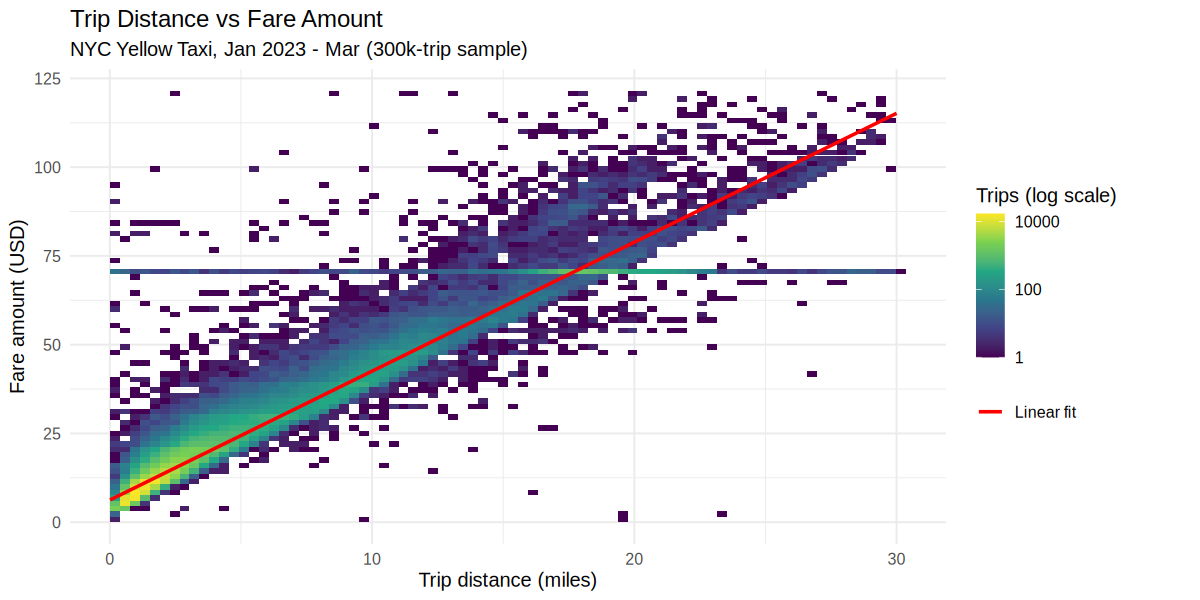

In [28]:
# 10. Payment-type distribution by pickup borough
ggplot(pay_borough, aes(PU_Borough, N, fill = payment_type)) + geom_col(position = "fill") +
  scale_y_continuous(labels = percent) + scale_fill_brewer(palette = "Dark2") +
  labs(title = "Payment Type Distribution by Pickup Borough", subtitle = sub, x = "Pickup borough", y = "Share of trips (%)", fill = "Payment type")
cat(sprintf("Interpretation: %s dominates overall (%.1f%% of trips), followed by %s (%.1f%%).\n",
            pay_total$payment_type[1], pay_total$pct[1], pay_total$payment_type[2], pay_total$pct[2]))

# 11. Trip distance vs fare
ps <- taxi[trip_distance <= 30 & fare_amount <= 120][sample(.N, min(.N, 3e5))]
ggplot(ps, aes(trip_distance, fare_amount)) + geom_bin_2d(bins = 80) + scale_fill_viridis_c(trans = "log10") +
  geom_smooth(aes(colour = "Linear fit"), method = "lm", formula = y ~ x, se = FALSE, linewidth = 1) +
  scale_colour_manual(values = c("Linear fit" = "red")) +
  labs(title = "Trip Distance vs Fare Amount", subtitle = paste(sub, "(300k-trip sample)"), x = "Trip distance (miles)", y = "Fare amount (USD)",
       fill = "Trips (log scale)", colour = NULL)
cat("Interpretation: fare grows almost linearly with distance (metered rate); the horizontal band at ~$70 is the JFK flat fare.\n")

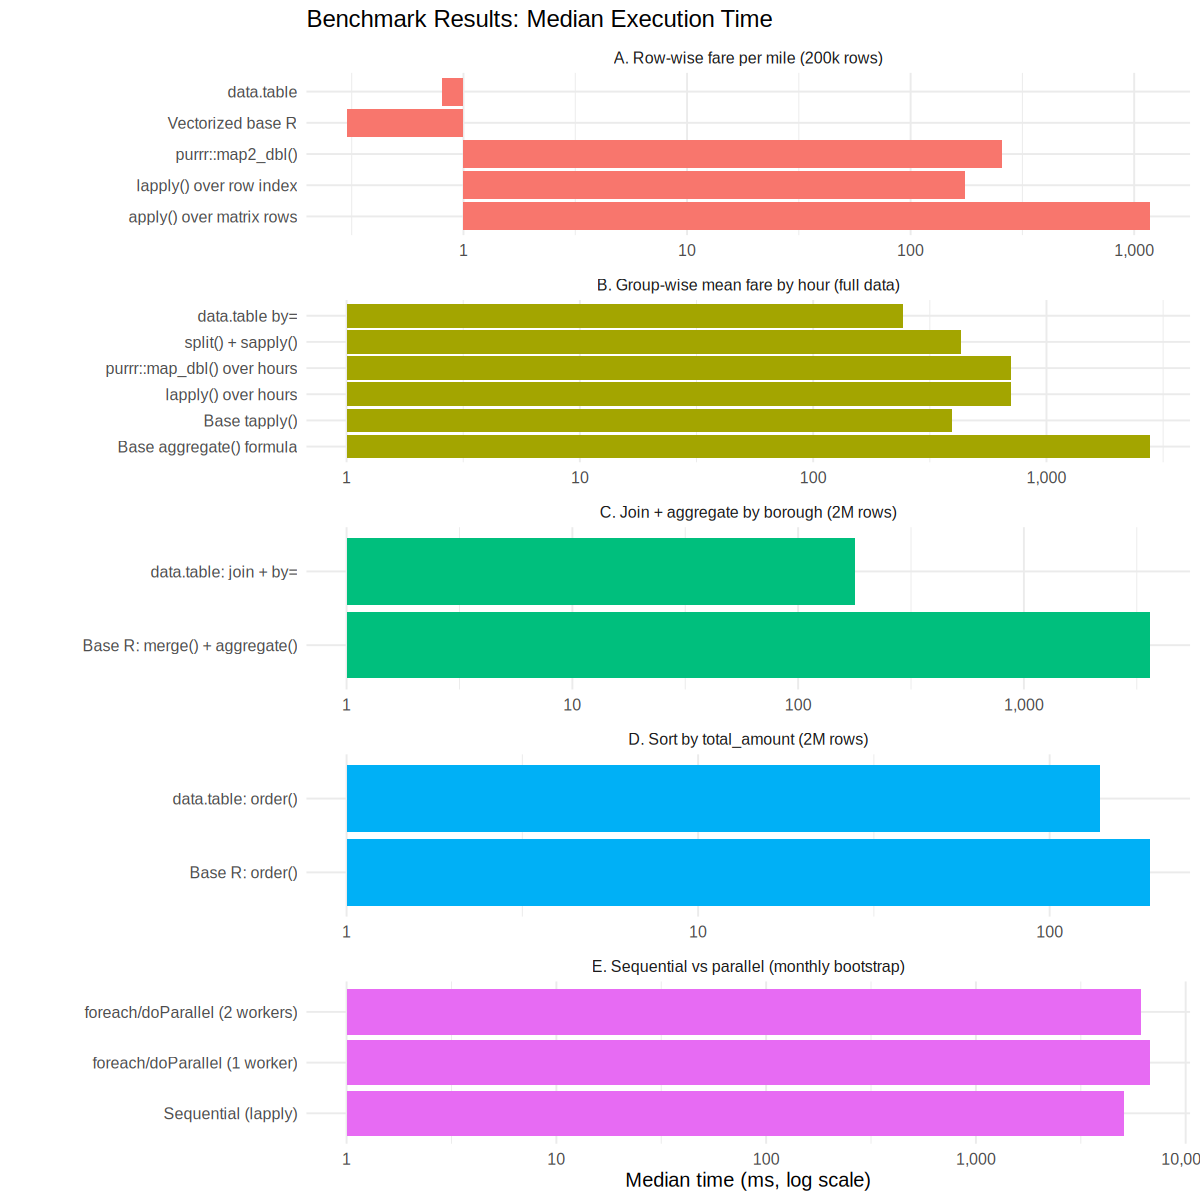

In [29]:
options(repr.plot.height = 10)
all_bench[, id := factor(paste(category, method, sep = "|"), levels = unique(paste(category, method, sep = "|")))]
ggplot(all_bench, aes(id, median_ms, fill = category)) + geom_col() + coord_flip() +
  facet_wrap(~ category, scales = "free", ncol = 1, labeller = label_wrap_gen(70)) +
  scale_x_discrete(labels = function(x) sub(".*\\|", "", x)) + scale_y_log10(labels = comma) + guides(fill = "none") +
  labs(title = "Benchmark Results: Median Execution Time", x = NULL, y = "Median time (ms, log scale)")
options(repr.plot.height = 5)

In [30]:
# Borough centroids are approximate (the zone lookup table has no coordinates)
cent <- data.table(Borough = c("Manhattan", "Brooklyn", "Queens", "Bronx", "Staten Island", "EWR"),
                   lat = c(40.7831, 40.6782, 40.7282, 40.8448, 40.5795, 40.6895),
                   lng = c(-73.9712, -73.9442, -73.7949, -73.8648, -74.1502, -74.1745))
bor <- taxi[, .(trips = .N, revenue = sum(total_amount), avg_fare = mean(fare_amount)), by = .(Borough = PU_Borough)][cent, on = "Borough", nomatch = NULL]

if (requireNamespace("leaflet", quietly = TRUE)) {
  library(leaflet)
  m <- leaflet(bor) |> addProviderTiles("CartoDB.Positron") |>
    addCircleMarkers(~lng, ~lat, radius = ~sqrt(trips) / 60, fillOpacity = 0.6, color = "#e41a1c",
                     popup = ~sprintf("<b>%s</b><br>Trips: %s<br>Revenue: $%s<br>Avg fare: $%.2f", Borough,
                                      format(trips, big.mark = ","), format(round(revenue), big.mark = ","), avg_fare))
  htmlwidgets::saveWidget(m, "taxi_borough_map.html", selfcontained = FALSE)  # open locally if Colab doesn't render it
  m
}

HTML widgets cannot be represented in plain text (need html)

In [31]:
cat("=== Summary of measured results ===\n")
print(fastest)
cat(sprintf("\nBest parallel speedup: %.2fx using %d workers (efficiency %.0f%%)\n", best$speedup, best$workers, best$efficiency_pct))
g <- bench_all$groupwise; r <- bench_all$rowwise
cat(sprintf("Group-wise: data.table is %.0fx faster than base aggregate() and %.0fx faster than lapply().\n",
            g[method == "Base aggregate() formula", median_ms] / g[method == "data.table by=", median_ms],
            g[method == "lapply() over hours", median_ms] / g[method == "data.table by=", median_ms]))
cat(sprintf("Row-wise: vectorized is %.0fx faster than apply() and %.0fx faster than purrr::map2_dbl().\n",
            r[method == "apply() over matrix rows", median_ms] / r[method == "Vectorized base R", median_ms],
            r[method == "purrr::map2_dbl()", median_ms] / r[method == "Vectorized base R", median_ms]))
sessionInfo()

=== Summary of measured results ===
                                        category                fastest
                                          <char>                 <char>
1:         A. Row-wise fare per mile (200k rows)      Vectorized base R
2:   B. Group-wise mean fare by hour (full data)         data.table by=
3:      C. Join + aggregate by borough (2M rows) data.table: join + by=
4:             D. Sort by total_amount (2M rows)    data.table: order()
5: E. Sequential vs parallel (monthly bootstrap)    Sequential (lapply)
   median_ms
       <num>
1:       0.3
2:     242.1
3:     178.1
4:     139.4
5:    5084.0

Best parallel speedup: 0.83x using 2 workers (efficiency 42%)
Group-wise: data.table is 11x faster than base aggregate() and 3x faster than lapply().
Row-wise: vectorized is 3997x faster than apply() and 869x faster than purrr::map2_dbl().


R version 4.6.1 (2026-06-24)
Platform: x86_64-pc-linux-gnu
Running under: Ubuntu 24.04.5 LTS

Matrix products: default
BLAS:   /usr/lib/x86_64-linux-gnu/openblas-pthread/libblas.so.3 
LAPACK: /usr/lib/x86_64-linux-gnu/openblas-pthread/libopenblasp-r0.3.26.so;  LAPACK version 3.12.0

locale:
 [1] LC_CTYPE=en_US.UTF-8       LC_NUMERIC=C              
 [3] LC_TIME=en_US.UTF-8        LC_COLLATE=en_US.UTF-8    
 [5] LC_MONETARY=en_US.UTF-8    LC_MESSAGES=en_US.UTF-8   
 [7] LC_PAPER=en_US.UTF-8       LC_NAME=C                 
 [9] LC_ADDRESS=C               LC_TELEPHONE=C            
[11] LC_MEASUREMENT=en_US.UTF-8 LC_IDENTIFICATION=C       

time zone: Etc/UTC
tzcode source: system (glibc)

attached base packages:
[1] parallel  stats     graphics  grDevices utils     datasets  methods  
[8] base     

other attached packages:
 [1] leaflet_2.2.3        scales_1.4.0         lubridate_1.9.5     
 [4] purrr_1.2.2          microbenchmark_1.5.0 doParallel_1.0.17   
 [7] iterators_1.0.14     for